In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

import time
import joblib as job
import pprint
import optuna
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import r2_score

In [2]:
# Lucky number
random_state = 42

In [3]:
# Loading dataset
dataset = pd.read_csv('../../data/3-processed/phase1.csv')
dataset.head()

,sampleid,answerdate,sex,age,ageid,prefecture,area,married,child,hincome,...,med_group,physical_group,mental_group,covid_group,k6_group3,k6_group2,phq9_%,phq9_item9,phq9_si,lsns_group
0,1759,2020-05-12,1.0,55.0,10.0,40.0,8.0,2.0,2.0,4.0,...,4.0,4.0,4.0,4.0,2.0,2.0,0.0,1.0,1.0,0.0
1,3474,2020-05-11,1.0,57.0,10.0,27.0,5.0,2.0,2.0,4.0,...,3.0,4.0,1.0,4.0,1.0,1.0,0.0,0.0,0.0,1.0
2,3793,2020-05-11,1.0,53.0,9.0,40.0,8.0,2.0,2.0,4.0,...,3.0,4.0,4.0,4.0,1.0,1.0,0.0,0.0,0.0,1.0
3,8488,2020-05-11,2.0,57.0,10.0,27.0,5.0,2.0,1.0,10.0,...,4.0,4.0,4.0,4.0,2.0,2.0,0.0,0.0,0.0,1.0
4,9703,2020-05-12,2.0,66.0,11.0,28.0,5.0,2.0,2.0,7.0,...,4.0,4.0,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0


In [4]:
dataset.columns.tolist()

['sampleid',
 'answerdate',
 'sex',
 'age',
 'ageid',
 'prefecture',
 'area',
 'married',
 'child',
 'hincome',
 'pincome',
 'job',
 'med_self',
 'med_fam',
 'current_physical',
 'past_physical',
 'current_mental',
 'past_mental',
 'current_covid19',
 'past_covid19',
 'maia_1',
 'maia_2',
 'maia_3',
 'maia_4',
 'maia_5',
 'maia_6',
 'maia_7',
 'maia_8',
 'sss8',
 'shai',
 'shs',
 'ucla',
 'k6',
 'phq9',
 'lsns6',
 'exercise',
 'healthydiet',
 'activity',
 'interaction_offline',
 'interaction_online',
 'altruistic',
 'optimism',
 'healthysleep',
 'deteriorationeconomy',
 'deteriorationinteract',
 'frustration',
 'covidanxiety',
 'covidsleepless',
 'difficultyliving',
 'difficultywork',
 'age_group',
 'hincome_group',
 'job_group',
 'med_group',
 'physical_group',
 'mental_group',
 'covid_group',
 'k6_group3',
 'k6_group2',
 'phq9_%',
 'phq9_item9',
 'phq9_si',
 'lsns_group']

In [5]:
# Setting attributes
dataset = dataset[[
        'sex',                      # 1 - Male; 2 - Female
        'age',                      # Age    
        'married',                  # 1 - Unmarried; 2 - Married
        'child',                    # 1 - No children; 2 - With children
        'hincome',                  # 1 to 9, increasing annual household income
        #'pincome',                  # Same categorization as HINCOME
        
        'job_group',                # 1 - Employed; 2 - Homemaker; 3 - Student; 4 - Unemployed; 5 - Others

        # 1 - Yes; 2 - No
        'med_self',                 # I am a healthcare professional (doctor, nurse, other healthcare professional, pharmacist, caregiver, etc.)
        'med_fam',                  # Have a family member who is a healthcare worker
        'current_physical',         # Whether the respondent has been treated for a physical illness in the past
        'past_physical',            # Whether the respondent is currently being treated for a mental disorder
        'current_mental',           # Whether the respondent has been treated for mental illness in the past
        'past_mental',              # Currently being treated for COVID-19
        'current_covid19',          # Currently undergoing treatment for COVID-19.
        'past_covid19',             # Have received treatment for COVID-19 in the past.
        
        # 1: Not at all true - 7: Very true
        'exercise',                 # I try to exercise to stay healthy (both indoors and outdoors). 
        'healthydiet',              # I ate meals with nutritional balance in mind.
        'healthysleep',             # My wake up and bedtimes were pretty consistent.
        'activity',                 # I engaged in hobbies and other activities that I could become passionate about.
        'interaction_offline',      # I interacted with family and friends in person (excluding work and classes).
        'interaction_online',       # Interacted with family and friends online via chat or video calls (excluding work or class).
        
        'altruistic',               # In order to prevent spreading the COVID-19 virus to family members and others, you voluntarily limited your outings and took preventive measures (such as wearing a mask).
        'optimism',                 # I thought positively about the future.
        'deteriorationeconomy',     # The economic situation worsened.
        'deteriorationinteract',    # Relationships with close people such as family and friends have deteriorated.
        'frustration',              # Changes in my life sometimes made me irritable and angry.
        'covidanxiety',             # Watching the news about the new coronavirus made me feel nervous and anxious.
        'covidsleepless',           # I couldn't sleep because I was worried about catching the new coronavirus.
        'difficultyliving',         # Daily life was disrupted, with shortages of COVID-19 prevention supplies (masks, thermometers, etc.) and other daily necessities.
        'difficultywork',           # Changes in my lifestyle have caused problems with my work and studies.
 
        'k6',                       # Psychological stress
        'phq9',                     # Depression
        'lsns6',                    # Social Network
        'sss8',                     # Somatic symptoms
        'shai',                     # Health anxiety
        'shs',                      # Subjective well-being
        
        'ucla'                      # Loneliness
    ]]
dataset

,sex,age,married,child,hincome,job_group,med_self,med_fam,current_physical,past_physical,...,covidsleepless,difficultyliving,difficultywork,k6,phq9,lsns6,sss8,shai,shs,ucla
0,1.0,55.0,2.0,2.0,4.0,1.0,2.0,2.0,2.0,2.0,...,4.0,4.0,3.0,10.0,6.0,15.0,0.0,0.0,4.00,25.0
1,1.0,57.0,2.0,2.0,4.0,1.0,2.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,5.0,9.0,0.0,0.0,3.50,26.0
2,1.0,53.0,2.0,2.0,4.0,1.0,2.0,1.0,2.0,2.0,...,5.0,5.0,5.0,3.0,8.0,3.0,17.0,2.0,4.00,26.0
3,2.0,57.0,2.0,1.0,10.0,2.0,2.0,2.0,2.0,2.0,...,1.0,5.0,1.0,8.0,4.0,5.0,8.0,2.0,3.75,33.0
4,2.0,66.0,2.0,2.0,7.0,2.0,2.0,2.0,2.0,2.0,...,1.0,1.0,4.0,1.0,0.0,19.0,4.0,0.0,3.25,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6718,2.0,49.0,2.0,1.0,10.0,5.0,2.0,2.0,2.0,2.0,...,1.0,1.0,3.0,1.0,0.0,7.0,1.0,0.0,7.00,21.0
6719,2.0,19.0,1.0,1.0,3.0,3.0,2.0,2.0,2.0,2.0,...,4.0,4.0,4.0,0.0,0.0,19.0,0.0,0.0,4.00,16.0
6720,1.0,37.0,1.0,1.0,NaN,5.0,2.0,2.0,2.0,2.0,...,4.0,1.0,1.0,9.0,2.0,8.0,2.0,4.0,2.50,26.0
6721,2.0,27.0,1.0,1.0,NaN,1.0,2.0,2.0,2.0,2.0,...,4.0,4.0,4.0,3.0,5.0,13.0,12.0,2.0,5.00,22.0


# Preprocessing

In [6]:
dataset_cleaned = dataset.copy()

In [7]:
from sklearn.impute import KNNImputer

# Use KNN imputation instead of dropping
imputer = KNNImputer(n_neighbors=5)
dataset_cleaned = pd.DataFrame(
    imputer.fit_transform(dataset_cleaned), 
    columns=dataset_cleaned.columns
)

In [8]:
# dataset_cleaned.columns[dataset_cleaned.isna().any()].tolist()

In [9]:
# mode_value = dataset_cleaned.loc[~dataset_cleaned['hincome'].isin([10]) & dataset_cleaned['hincome'].notna(), 'hincome'].mode()[0]
# dataset_cleaned['hincome'] = dataset_cleaned['hincome'].replace([10, np.nan], mode_value)

In [10]:
# mode_value = dataset_cleaned.loc[~dataset_cleaned['pincome'].isin([10]) & dataset_cleaned['pincome'].notna(), 'pincome'].mode()[0]
# dataset_cleaned['pincome'] = dataset_cleaned['pincome'].replace([10, np.nan], mode_value)

In [11]:
# dataset_cleaned.columns[dataset_cleaned.isna().any()].tolist()

In [12]:
# Scale numerical features using RobustScaler to handle outliers better:
from sklearn.preprocessing import RobustScaler

# Scale age and hincome
numeric_features = ['age', 'hincome']
scaler = RobustScaler()
dataset_cleaned[numeric_features] = scaler.fit_transform(dataset_cleaned[numeric_features])

In [13]:
# Sex: 1 - Male; 2 - Female
column = 'sex'
def categories(x):
    if x == 1:
        return 'Male'
    elif x == 2:
        return 'Female'
    else:
        return None
dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

# Married: 1 - Unmarried; 2 - Married
column = 'married'
def categories(x):
    if x == 1:
        return 'Unmarried'
    elif x == 2:
        return 'Married'
    else:
        return None
dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

# Child: 1 - No children; 2 - With children
column = 'child'
def categories(x):
    if x == 1:
        return 'No children'
    elif x == 2:
        return 'With children'
    else:
        return None
dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

# # Household Income Group
# column = 'hincome'
# def categories(x):
#     if x == 1:
#         return 'Less than 2 million'
#     elif x == 2:
#         return '2 million to less than 4 million'
#     elif x == 3:
#         return '4 million to less than 6 million'
#     elif x == 4:
#         return '6 million to less than 8 million'
#     elif x == 5:
#         return '8 million to less than 10 million'
#     elif x == 6:
#         return '10 million to less than 12 million'
#     elif x == 7:
#         return '12 million to less than 15 million'
#     elif x == 8:
#         return '15 million to less than 20 million'
#     elif x == 9:
#         return '20 million yen or more'
#     else:
#         return None
# dataset_cleaned[column] = dataset_cleaned[column].apply(categories)
# 
# # Personal Annual Income
# column = 'pincome'
# def categories(x):
#     if x == 1:
#         return 'Less than 2 million'
#     elif x == 2:
#         return '2 million to less than 4 million'
#     elif x == 3:
#         return '4 million to less than 6 million'
#     elif x == 4:
#         return '6 million to less than 8 million'
#     elif x == 5:
#         return '8 million to less than 10 million'
#     elif x == 6:
#         return '10 million to less than 12 million'
#     elif x == 7:
#         return '12 million to less than 15 million'
#     elif x == 8:
#         return '15 million to less than 20 million'
#     elif x == 9:
#         return '20 million yen or more'
#     else:
#         return None
# dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

# Job Group
column = 'job_group'
def categories(x):
    if x == 1:
        return 'Employed'
    elif x == 2:
        return 'Homemaker'
    elif x == 3:
        return 'Student'
    elif x == 4: 
        return 'Unemployed'
    elif x == 5:
        return 'Others'
    else:
        return None
dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

In [14]:
dataset_cleaned 

,sex,age,married,child,hincome,job_group,med_self,med_fam,current_physical,past_physical,...,covidsleepless,difficultyliving,difficultywork,k6,phq9,lsns6,sss8,shai,shs,ucla
0,Male,0.409091,Married,With children,0.000000,Employed,2.0,2.0,2.0,2.0,...,4.0,4.0,3.0,10.0,6.0,15.0,0.0,0.0,4.00,25.0
1,Male,0.500000,Married,With children,0.000000,Employed,2.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,5.0,9.0,0.0,0.0,3.50,26.0
2,Male,0.318182,Married,With children,0.000000,Employed,2.0,1.0,2.0,2.0,...,5.0,5.0,5.0,3.0,8.0,3.0,17.0,2.0,4.00,26.0
3,Female,0.500000,Married,No children,2.500000,Homemaker,2.0,2.0,2.0,2.0,...,1.0,5.0,1.0,8.0,4.0,5.0,8.0,2.0,3.75,33.0
4,Female,0.909091,Married,With children,1.250000,Homemaker,2.0,2.0,2.0,2.0,...,1.0,1.0,4.0,1.0,0.0,19.0,4.0,0.0,3.25,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6718,Female,0.136364,Married,No children,2.500000,Others,2.0,2.0,2.0,2.0,...,1.0,1.0,3.0,1.0,0.0,7.0,1.0,0.0,7.00,21.0
6719,Female,-1.227273,Unmarried,No children,-0.416667,Student,2.0,2.0,2.0,2.0,...,4.0,4.0,4.0,0.0,0.0,19.0,0.0,0.0,4.00,16.0
6720,Male,-0.409091,Unmarried,No children,1.000000,Others,2.0,2.0,2.0,2.0,...,4.0,1.0,1.0,9.0,2.0,8.0,2.0,4.0,2.50,26.0
6721,Female,-0.863636,Unmarried,No children,-0.416667,Employed,2.0,2.0,2.0,2.0,...,4.0,4.0,4.0,3.0,5.0,13.0,12.0,2.0,5.00,22.0


In [15]:
columns = [
        'med_self',                 # I am a healthcare professional (doctor, nurse, other healthcare professional, pharmacist, caregiver, etc.)
        'med_fam',                  # Have a family member who is a healthcare worker
        'current_physical',         # Whether the respondent has been treated for a physical illness in the past
        'past_physical',            # Whether the respondent is currently being treated for a mental disorder
        'current_mental',           # Whether the respondent has been treated for mental illness in the past
        'past_mental',              # Currently being treated for COVID-19
        'current_covid19',          # Currently undergoing treatment for COVID-19.
        'past_covid19'              # Have received treatment for COVID-19 in the past.
]

def categories(x):
    if x == 1:
        return 'Yes'
    else:
        return 'No'

for column in columns:
    dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

In [16]:
dataset_cleaned

,sex,age,married,child,hincome,job_group,med_self,med_fam,current_physical,past_physical,...,covidsleepless,difficultyliving,difficultywork,k6,phq9,lsns6,sss8,shai,shs,ucla
0,Male,0.409091,Married,With children,0.000000,Employed,No,No,No,No,...,4.0,4.0,3.0,10.0,6.0,15.0,0.0,0.0,4.00,25.0
1,Male,0.500000,Married,With children,0.000000,Employed,No,Yes,No,No,...,1.0,1.0,1.0,1.0,5.0,9.0,0.0,0.0,3.50,26.0
2,Male,0.318182,Married,With children,0.000000,Employed,No,Yes,No,No,...,5.0,5.0,5.0,3.0,8.0,3.0,17.0,2.0,4.00,26.0
3,Female,0.500000,Married,No children,2.500000,Homemaker,No,No,No,No,...,1.0,5.0,1.0,8.0,4.0,5.0,8.0,2.0,3.75,33.0
4,Female,0.909091,Married,With children,1.250000,Homemaker,No,No,No,No,...,1.0,1.0,4.0,1.0,0.0,19.0,4.0,0.0,3.25,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6718,Female,0.136364,Married,No children,2.500000,Others,No,No,No,No,...,1.0,1.0,3.0,1.0,0.0,7.0,1.0,0.0,7.00,21.0
6719,Female,-1.227273,Unmarried,No children,-0.416667,Student,No,No,No,No,...,4.0,4.0,4.0,0.0,0.0,19.0,0.0,0.0,4.00,16.0
6720,Male,-0.409091,Unmarried,No children,1.000000,Others,No,No,No,No,...,4.0,1.0,1.0,9.0,2.0,8.0,2.0,4.0,2.50,26.0
6721,Female,-0.863636,Unmarried,No children,-0.416667,Employed,No,No,No,No,...,4.0,4.0,4.0,3.0,5.0,13.0,12.0,2.0,5.00,22.0


In [17]:
categorical_features = [
    'sex',
    'married',
    'child',
    'job_group',
    'med_self',                 # I am a healthcare professional (doctor, nurse, other healthcare professional, pharmacist, caregiver, etc.)
    'med_fam',                  # Have a family member who is a healthcare worker
    'current_physical',         # Whether the respondent has been treated for a physical illness in the past
    'past_physical',            # Whether the respondent is currently being treated for a mental disorder
    'current_mental',           # Whether the respondent has been treated for mental illness in the past
    'past_mental',              # Currently being treated for COVID-19
    'current_covid19',          # Currently undergoing treatment for COVID-19.
    'past_covid19',             # Have received treatment for COVID-19 in the past.
]

In [18]:
initial_rows = len(dataset)

# Drop rows with NaN values (originally non-numeric values)
dataset_cleaned = dataset_cleaned.dropna()

row_count = len(dataset_cleaned)

print(f"Total number of rows: {row_count}")
print(f"Number of rows dropped: {initial_rows - row_count}")

Total number of rows: 6723
Number of rows dropped: 0


In [19]:
initial_rows = len(dataset_cleaned)

# Drop outliers in hincome and pincome
# https://medium.com/artificial-intelligence-101/handling-outliers-in-data-a-step-by-step-guide-using-python-be8471a021a9
# Q1 = dataset_cleaned[['hincome', 'pincome']].quantile(0.25)
# Q3 = dataset_cleaned[['hincome', 'pincome']].quantile(0.75)
Q1 = dataset_cleaned[['hincome']].quantile(0.25)
Q3 = dataset_cleaned[['hincome']].quantile(0.75)
IQR = Q3 - Q1

# Calculate lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# # Filtering out outliers
# dataset_cleaned = dataset_cleaned[~((dataset_cleaned[['hincome', 'pincome']] < lower_bound | 
#                                     (dataset_cleaned[['hincome', 'pincome']] > upper_bound))).any(axis=1)]
# Filtering out outliers
dataset_cleaned = dataset_cleaned[~((dataset_cleaned[['hincome']] < lower_bound | 
                                    (dataset_cleaned[['hincome']] > upper_bound))).any(axis=1)]

# Get final number of rows
row_count = len(dataset_cleaned)

# Print number of dropped rows
print(f"Total number of rows: {row_count}")
print(f"Number of rows dropped: {initial_rows - row_count}")

Total number of rows: 1142
Number of rows dropped: 5581


In [20]:
dataset_cleaned = pd.get_dummies(dataset_cleaned, columns=categorical_features, drop_first=True)

In [21]:
dataset_cleaned

,age,hincome,exercise,healthydiet,healthysleep,activity,interaction_offline,interaction_online,altruistic,optimism,...,job_group_Student,job_group_Unemployed,med_self_Yes,med_fam_Yes,current_physical_Yes,past_physical_Yes,current_mental_Yes,past_mental_Yes,current_covid19_Yes,past_covid19_Yes
3,0.500000,2.500000,5.0,5.0,7.0,7.0,5.0,5.0,7.0,3.0,...,False,False,False,False,False,False,False,False,False,False
4,0.909091,1.250000,7.0,6.0,7.0,6.0,7.0,6.0,7.0,4.0,...,False,False,False,False,False,False,False,False,False,False
10,0.590909,1.250000,1.0,3.0,3.0,1.0,3.0,3.0,3.0,3.0,...,False,False,False,False,False,False,False,False,False,False
13,0.136364,2.500000,3.0,3.0,4.0,4.0,1.0,1.0,7.0,2.0,...,False,False,False,False,False,False,False,False,False,False
19,0.409091,2.083333,7.0,6.0,6.0,3.0,5.0,1.0,7.0,4.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6690,-0.409091,1.666667,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,...,False,False,False,False,False,False,False,False,False,False
6691,0.000000,2.500000,1.0,1.0,5.0,1.0,1.0,1.0,7.0,1.0,...,False,False,False,False,False,False,False,True,False,False
6693,0.227273,2.083333,4.0,6.0,6.0,6.0,1.0,6.0,7.0,7.0,...,False,False,False,False,False,False,False,True,False,False
6718,0.136364,2.500000,1.0,7.0,7.0,6.0,4.0,1.0,7.0,7.0,...,False,False,False,False,False,False,False,False,False,False


In [22]:
likert_columns = [
        'exercise',                 # I try to exercise to stay healthy (both indoors and outdoors). 
        'healthydiet',              # I ate meals with nutritional balance in mind.
        'healthysleep',             # My wake up and bedtimes were pretty consistent.
        'activity',                 # I engaged in hobbies and other activities that I could become passionate about.
        'interaction_offline',      # I interacted with family and friends in person (excluding work and classes).
        'interaction_online',       # Interacted with family and friends online via chat or video calls (excluding work or class).
        
        'altruistic',               # In order to prevent spreading the COVID-19 virus to family members and others, you voluntarily limited your outings and took preventive measures (such as wearing a mask).
        'optimism',                 # I thought positively about the future.
        'deteriorationeconomy',     # The economic situation worsened.
        'deteriorationinteract',    # Relationships with close people such as family and friends have deteriorated.
        'frustration',              # Changes in my life sometimes made me irritable and angry.
        'covidanxiety',             # Watching the news about the new coronavirus made me feel nervous and anxious.
        'covidsleepless',           # I couldn't sleep because I was worried about catching the new coronavirus.
        'difficultyliving',         # Daily life was disrupted, with shortages of COVID-19 prevention supplies (masks, thermometers, etc.) and other daily necessities.
        'difficultywork',           # Changes in my lifestyle have caused problems with my work and studies.
]

In [23]:
# Convert Likert scale to numeric values
likert_mapping = {str(i): i for i in range(1, 8)}
dataset_cleaned[likert_columns] = dataset_cleaned[likert_columns].replace(likert_mapping)

In [24]:
# Scale Likert features to [-1,1] range
def scale_likert(x):
    return (x - 4) / 3  # Centers at 0 and scales to [-1,1]

dataset_cleaned[likert_columns] = dataset_cleaned[likert_columns].apply(scale_likert)

In [25]:
# Create interaction features
dataset_cleaned['age_income'] = dataset_cleaned['age'] * dataset_cleaned['hincome']
dataset_cleaned['stress_anxiety'] = dataset_cleaned['k6'] * dataset_cleaned['covidanxiety']
dataset_cleaned['physical_mental'] = dataset_cleaned['current_physical_Yes'] * dataset_cleaned['current_mental_Yes']

In [26]:
feature_groups = {
    'demographic': ['age', 'hincome', 'sex_Male', 'married_Unmarried', 'child_With children'],
    'health': ['med_self_Yes', 'current_physical_Yes', 'current_mental_Yes'],
    'covid': ['current_covid19_Yes', 'past_covid19_Yes'],  
    'lifestyle': likert_columns,
    'psychological': ['k6', 'phq9', 'shai', 'ucla']
}

# Convert to feature indices for LightGBM
feature_indices = []
for group in feature_groups.values():
    indices = [dataset_cleaned.columns.get_loc(col) for col in group]
    feature_indices.append(indices)

In [27]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features for psychological scores
psych_features = ['k6', 'phq9', 'shai']
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(dataset_cleaned[psych_features])

# Get feature names for interactions only
feature_names = poly.get_feature_names_out(psych_features)
interaction_names = feature_names[len(psych_features):]
poly_columns = [f'poly_{name}' for name in interaction_names]

# Concatenate only interaction terms
dataset_cleaned = pd.concat([
    dataset_cleaned,
    pd.DataFrame(poly_features[:, len(psych_features):], columns=poly_columns)
], axis=1)

In [28]:
dataset_cleaned

,age,hincome,exercise,healthydiet,healthysleep,activity,interaction_offline,interaction_online,altruistic,optimism,...,past_covid19_Yes,age_income,stress_anxiety,physical_mental,poly_k6^2,poly_k6 phq9,poly_k6 shai,poly_phq9^2,poly_phq9 shai,poly_shai^2
3,0.500000,2.500000,0.333333,0.333333,1.000000,1.000000,0.333333,0.333333,1.000000,-0.333333,...,False,1.250000,2.666667,False,25.0,70.0,10.0,196.0,28.0,4.0
4,0.909091,1.250000,1.000000,0.666667,1.000000,0.666667,1.000000,0.666667,1.000000,0.000000,...,False,1.136364,0.333333,False,0.0,0.0,0.0,0.0,0.0,4.0
10,0.590909,1.250000,-1.000000,-0.333333,-0.333333,-1.000000,-0.333333,-0.333333,-0.333333,-0.333333,...,False,0.738636,-0.333333,False,81.0,27.0,0.0,9.0,0.0,0.0
13,0.136364,2.500000,-0.333333,-0.333333,0.000000,0.000000,-1.000000,-1.000000,1.000000,-0.666667,...,False,0.340909,0.000000,False,1.0,2.0,0.0,4.0,0.0,0.0
19,0.409091,2.083333,1.000000,0.666667,0.666667,-0.333333,0.333333,-1.000000,1.000000,0.000000,...,False,0.852273,-0.000000,False,0.0,0.0,0.0,0.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1136,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
1137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
1138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,64.0,64.0,0.0,64.0,0.0,0.0
1140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0


# Train-Test Split

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [30]:
y = dataset_cleaned['ucla']
X = dataset_cleaned.drop(columns=['ucla'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [31]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

In [32]:
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Model Training

In [33]:
# https://www.geeksforgeeks.org/random-forest-regression-in-python/
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [34]:
baseline_model = RandomForestRegressor(random_state=random_state)
baseline_model.fit(X_train_scaled, y_train_scaled.ravel())

ValueError: Input y contains NaN.

In [28]:
def evaluate(model, X_test_scaled, y_test):
    y_pred_scaled = model.predict(X_test_scaled)
    
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
    
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Predicted vs Actual Values")
    plt.show()
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{model.__class__.__name__}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}")
    print("-" * 30)
    
    return r2

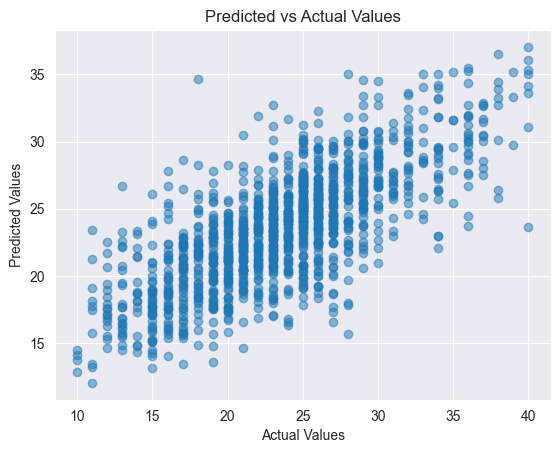

RandomForestRegressor:
  MAE: 2.9629
  MSE: 14.9689
  RMSE: 3.8690
  R²: 0.5448
------------------------------


0.5448469999157571

In [29]:
evaluate(baseline_model, X_test_scaled, y_test)

# Model Tuning

In [30]:
pp = pprint.PrettyPrinter(indent=1)

# === OPTUNA HYPERPARAMETER TUNING ===
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': random_state,
        'n_jobs': -1
    }

    model = RandomForestRegressor(**params)
    score = cross_val_score(model, X_train_scaled, y_train_scaled.ravel(), cv=5, scoring='r2', n_jobs=-1)
    return score.mean()  # Return R² directly since we want to maximize it

In [31]:
def run_optuna_tuning():
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=30, timeout=1800)  # 30 trials, 30 min timeout

    print("Best parameters:")
    pp.pprint(study.best_params)
    
    model = RandomForestRegressor(**study.best_params, 
                                random_state=random_state, 
                                n_jobs=-1)
    model.fit(X_train_scaled, y_train_scaled.ravel())
    
    print('\nOptuna-tuned model performance:')
    evaluate(model, X_test_scaled, y_test)
    
    return model, study.best_params

In [32]:
# === GRIDSEARCHCV PLOT ===
def plot_cv(tuner):
    results = tuner.cv_results_
    cv_params = tuner.param_grid
    means_test = results['mean_test_score']
    stds_test = results['std_test_score']
    means_train = results.get('mean_train_score', np.zeros_like(means_test))
    stds_train = results.get('std_train_score', np.zeros_like(stds_test))

    fig, ax = plt.subplots(1, len(cv_params), sharey=True, figsize=(20, 8), dpi=300)
    fig.suptitle('Hyperparameter Tuning')
    fig.text(0.04, 0.5, 'MEAN SCORE', va='center', rotation='vertical')

    for i, (param, values) in enumerate(cv_params.items()):
        scores = []
        for v in values:
            mask = results['param_' + param] == v
            scores.append((
                str(v),
                np.mean(means_train[mask]),
                np.std(stds_train[mask]),
                np.mean(means_test[mask]),
                np.std(stds_test[mask])
            ))

        x, y1, e1, y2, e2 = zip(*scores)
        ax[i].errorbar(x, y1, e1, linestyle='-', marker='^', label='Train')
        ax[i].errorbar(x, y2, e2, linestyle='--', marker='o', color='g', label='CV')
        ax[i].set_xlabel(param.upper())

    plt.legend()
    plt.show()

[I 2025-04-23 17:52:52,410] A new study created in memory with name: no-name-7029152d-e079-4201-bde7-9d897b4f90af
[I 2025-04-23 17:52:55,492] Trial 0 finished with value: 0.48650902686906283 and parameters: {'n_estimators': 907, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.48650902686906283.
[I 2025-04-23 17:52:58,450] Trial 1 finished with value: 0.5421869303994601 and parameters: {'n_estimators': 547, 'max_depth': 32, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 0.5421869303994601.
[I 2025-04-23 17:53:03,103] Trial 2 finished with value: 0.5431751320156207 and parameters: {'n_estimators': 825, 'max_depth': 45, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 2 with value: 0.5431751320156207.
[I 2025-04-23 17:53:07,367] Trial 3 finished with value: 0.5448731966462332

Best parameters:
{'bootstrap': False,
 'max_depth': 50,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 992}

Optuna-tuned model performance:


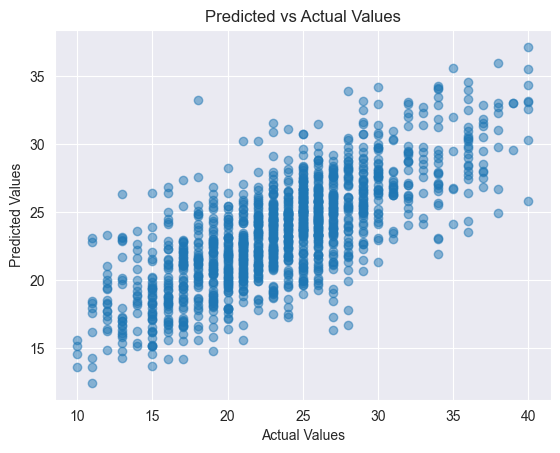

RandomForestRegressor:
  MAE: 2.9550
  MSE: 14.8585
  RMSE: 3.8547
  R²: 0.5482
------------------------------


In [33]:
optuna_model, best_params = run_optuna_tuning()

In [36]:
# Train Lasso model
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize and fit Lasso
Lreg = linear_model.Lasso(alpha=0.5)
Lreg.fit(X_train_scaled, y_train_scaled.ravel())

# Make predictions
y_pred = Lreg.predict(X_test_scaled)

# Calculate metrics
mae = mean_absolute_error(y_test_scaled, y_pred)
mse = mean_squared_error(y_test_scaled, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_scaled, y_pred)

# Print results
print("Lasso Regression:")
print(f"  MAE: {mae:.4f}")
print(f"  MSE: {mse:.4f}") 
print(f"  RMSE: {rmse:.4f}")
print(f"  R²: {r2:.4f}")
print("-" * 30)

Lasso Regression:
  MAE: 0.7513
  MSE: 0.9239
  RMSE: 0.9612
  R²: 0.0837
------------------------------


In [37]:
# Import libraries
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train XGBoost
xgb_model = xgb.XGBRegressor(random_state=42)
xgb_model.fit(X_train_scaled, y_train_scaled.ravel())

# XGBoost predictions
xgb_pred = xgb_model.predict(X_test_scaled)

# XGBoost metrics
xgb_mae = mean_absolute_error(y_test_scaled, xgb_pred)
xgb_mse = mean_squared_error(y_test_scaled, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test_scaled, xgb_pred)

print("XGBoost:")
print(f"  MAE: {xgb_mae:.4f}")
print(f"  MSE: {xgb_mse:.4f}")
print(f"  RMSE: {xgb_rmse:.4f}")
print(f"  R²: {xgb_r2:.4f}")
print("-" * 30)

# Train LightGBM
lgb_model = lgb.LGBMRegressor(random_state=42)
lgb_model.fit(X_train_scaled, y_train_scaled.ravel())

# LightGBM predictions
lgb_pred = lgb_model.predict(X_test_scaled)

# LightGBM metrics
lgb_mae = mean_absolute_error(y_test_scaled, lgb_pred)
lgb_mse = mean_squared_error(y_test_scaled, lgb_pred)
lgb_rmse = np.sqrt(lgb_mse)
lgb_r2 = r2_score(y_test_scaled, lgb_pred)

print("LightGBM:")
print(f"  MAE: {lgb_mae:.4f}")
print(f"  MSE: {lgb_mse:.4f}")
print(f"  RMSE: {lgb_rmse:.4f}")
print(f"  R²: {lgb_r2:.4f}")
print("-" * 30)

XGBoost:
  MAE: 0.5473
  MSE: 0.5072
  RMSE: 0.7122
  R²: 0.4969
------------------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000392 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 392
[LightGBM] [Info] Number of data points in the train set: 5378, number of used features: 36
[LightGBM] [Info] Start training from score 0.000000
LightGBM:
  MAE: 0.5169
  MSE: 0.4575
  RMSE: 0.6764
  R²: 0.5463
------------------------------


In [39]:
import optuna
from sklearn.metrics import mean_squared_error

def objective(trial):
    # Define hyperparameter search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42
    }
    
    # Create and train model
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train_scaled, y_train_scaled.ravel())
    
    # Make predictions
    predictions = model.predict(X_test_scaled)
    
    # Calculate error
    rmse = np.sqrt(mean_squared_error(y_test_scaled, predictions))
    return rmse

# Create and run study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Get best parameters
best_params = study.best_params

# Train final model with best parameters
final_model = lgb.LGBMRegressor(**best_params)
final_model.fit(X_train_scaled, y_train_scaled.ravel())

# Evaluate final model
y_pred = final_model.predict(X_test_scaled)
mae = mean_absolute_error(y_test_scaled, y_pred)
mse = mean_squared_error(y_test_scaled, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_scaled, y_pred)

print("Optimized LightGBM:")
print(f"  MAE: {mae:.4f}")
print(f"  MSE: {mse:.4f}")
print(f"  RMSE: {rmse:.4f}") 
print(f"  R²: {r2:.4f}")
print("-" * 30)
print("\nBest Parameters:")
for param, value in best_params.items():
    print(f"{param}: {value}")

[I 2025-04-23 18:02:29,796] A new study created in memory with name: no-name-0d92c79e-bf87-43bb-a5e4-e485e3492cda


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 398
[LightGBM] [Info] Number of data points in the train set: 5378, number of used features: 38
[LightGBM] [Info] Start training from score 0.000000


[I 2025-04-23 18:02:30,216] Trial 0 finished with value: 0.6798350901521352 and parameters: {'n_estimators': 483, 'learning_rate': 0.06976662165694777, 'max_depth': 11, 'num_leaves': 71, 'min_child_samples': 6, 'subsample': 0.8350596378100879, 'colsample_bytree': 0.5603782187364783, 'reg_alpha': 0.48427183375018823, 'reg_lambda': 0.22163328611406186}. Best is trial 0 with value: 0.6798350901521352.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000218 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 398
[LightGBM] [Info] Number of data points in the train set: 5378, number of used features: 38
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2025-04-23 18:02:30,420] Trial 1 finished with value: 0.6789227857710263 and parameters: {'n_estimators': 316, 'learning_rate': 0.06021506080796915, 'max_depth': 11, 'num_leaves': 51, 'min_child_samples': 11, 'subsample': 0.6308859758728672, 'colsample_bytree': 0.7801926729347797, 'reg_alpha': 0.5373449765433203, 'reg_lambda': 0.7329119994844207}. Best is trial 1 with value: 0.6789227857710263.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-04-23 18:02:39,131] Trial 48 finished with value: 0.6689949203829282 and parameters: {'n_estimators': 108, 'learning_rate': 0.05188397567964187, 'max_depth': 3, 'num_leaves': 51, 'min_child_samples': 95, 'subsample': 0.7559591538264845, 'colsample_bytree': 0.5782286585000485, 'reg_alpha': 0.7196713318813874, 'reg_lambda': 0.13381743727171444}. Best is trial 45 with value: 0.6632435277837568.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000182 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 392
[LightGBM] [Info] Number of data points in the train set: 5378, number of used features: 36
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-04-23 18:02:39,288] Trial 49 finished with value: 0.6668971442558468 and parameters: {'n_estimators': 201, 'learning_rate': 0.04837635040856785, 'max_depth': 12, 'num_leaves': 67, 'min_child_samples': 91, 'subsample': 0.666254233731659, 'colsample_bytree': 0.514391969654272, 'reg_alpha': 0.5168286537173927, 'reg_lambda': 0.2754456248716759}. Best is trial 45 with value: 0.6632435277837568.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 392
[LightGBM] [Info] Number of data points in the train set: 5378, number of used features: 36
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [40]:
!pip install torch-geometric

You should consider upgrading via the 'E:\py3-10\python.exe -m pip install --upgrade pip' command.


In [41]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data, DataLoader

# Define the GNN model
class GNN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        # Graph convolutions
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.1, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.1, training=self.training)
        
        x = self.conv3(x, edge_index)
        
        # Global pooling
        x = global_mean_pool(x, batch)
        
        # Final prediction
        x = self.lin(x)
        return x

# Training function
def train_gnn(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0
    
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = F.mse_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

# Convert data to PyG format and train
def run_gnn_training(X, y, edge_index, batch_size=32, epochs=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Convert to PyG Data objects
    dataset = []
    for i in range(len(X)):
        data = Data(
            x=torch.FloatTensor(X[i]),
            edge_index=edge_index,
            y=torch.FloatTensor([y[i]])
        )
        dataset.append(data)
    
    # Create data loader
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model
    model = GNN(num_features=X.shape[1], hidden_channels=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    # Training loop
    for epoch in range(epochs):
        loss = train_gnn(model, loader, optimizer, device)
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:03d}, Loss: {loss:.4f}')
    
    return model

In [44]:
# Evaluation function
def test_gnn(model, test_loader, device):
    model.eval()
    total_loss = 0
    preds = []
    truths = []

    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            loss = F.mse_loss(out, data.y)
            total_loss += loss.item()
            preds.append(out.cpu())
            truths.append(data.y.cpu())
    
    preds = torch.cat(preds, dim=0)
    truths = torch.cat(truths, dim=0)
    return total_loss / len(test_loader), preds, truths


In [45]:
# Updated pipeline function
def run_gnn_pipeline(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, edge_index_template, scaler_y, batch_size=32, epochs=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def create_dataset(X, y):
        dataset = []
        for i in range(len(X)):
            data = Data(
                x=torch.FloatTensor(X[i].reshape(1, -1)),  # 1 node per graph
                edge_index=edge_index_template,
                y=torch.FloatTensor([y[i]])
            )
            dataset.append(data)
        return dataset

    train_dataset = create_dataset(X_train_scaled, y_train_scaled)
    test_dataset = create_dataset(X_test_scaled, y_test_scaled)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    model = GNN(num_features=X_train_scaled.shape[1], hidden_channels=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        loss = train_gnn(model, train_loader, optimizer, device)
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:03d}, Train Loss: {loss:.4f}')

    test_loss, preds, truths = test_gnn(model, test_loader, device)

    # Inverse transform for interpretability
    preds_inv = scaler_y.inverse_transform(preds.numpy())
    truths_inv = scaler_y.inverse_transform(truths.numpy())

    # Metrics
    mse = mean_squared_error(truths_inv, preds_inv)
    mae = mean_absolute_error(truths_inv, preds_inv)
    r2 = r2_score(truths_inv, preds_inv)

    print(f"\n🔍 Evaluation Metrics:")
    print(f"  - MSE: {mse:.4f}")
    print(f"  - MAE: {mae:.4f}")
    print(f"  - R²:  {r2:.4f}")

    # Plot: predicted vs actual
    plt.figure(figsize=(6, 6))
    plt.scatter(truths_inv, preds_inv, alpha=0.7, edgecolors='k')
    plt.plot([truths_inv.min(), truths_inv.max()],
             [truths_inv.min(), truths_inv.max()], 'r--')
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title("Predicted vs True")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model, preds_inv, truths_inv

In [48]:
edge_index = torch.tensor([[0], [0]], dtype=torch.long)

E:\py3-10\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 010, Train Loss: 0.4359
Epoch 020, Train Loss: 0.4106
Epoch 030, Train Loss: 0.3668
Epoch 040, Train Loss: 0.3626
Epoch 050, Train Loss: 0.3493
Epoch 060, Train Loss: 0.3291
Epoch 070, Train Loss: 0.3063
Epoch 080, Train Loss: 0.3018
Epoch 090, Train Loss: 0.3810
Epoch 100, Train Loss: 0.2968

🔍 Evaluation Metrics:
  - MSE: 18.7109
  - MAE: 3.3694
  - R²:  0.4311


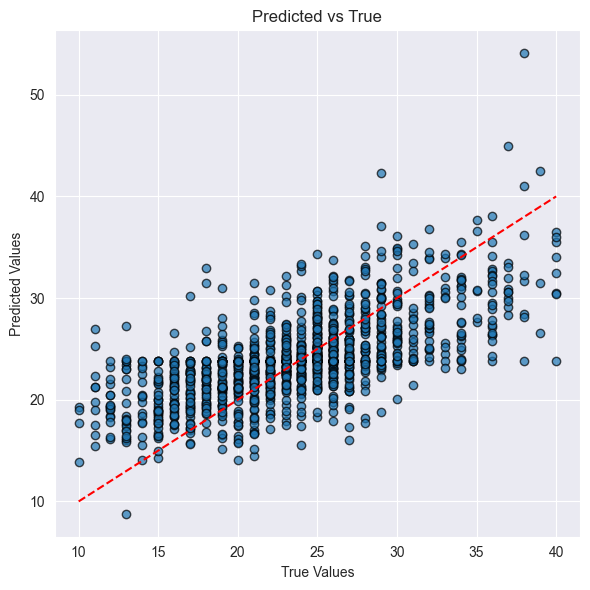

In [49]:
model, preds, truths = run_gnn_pipeline(
    X_train_scaled, y_train_scaled,
    X_test_scaled, y_test_scaled,
    edge_index_template=edge_index,  # just rename it here
    scaler_y=scaler_y,
    batch_size=32,
    epochs=100
)